# Домашнее задание 5


Структура задания:

1. выбор датасета;
2. выбор модели;
3. предварительная оценка качества на корзинке и `lm-evaluation-harness`;
4. QLoRA-дообучение;
5. оценка качества после обучения;
6. профайлинг через `torch.profiler.profile`;
7. выводы.


In [1]:
%%capture
!pip -q uninstall -y wandb
!pip -q install --upgrade pip
!pip -q install unsloth
!pip -q install --upgrade "transformers @ git+https://github.com/huggingface/transformers.git"
!pip -q install --upgrade trl peft accelerate bitsandbytes datasets evaluate sentencepiece protobuf
!pip -q install --upgrade lm-eval
!pip -q uninstall -y wandb


In [2]:
import json
import gc
import os
import random
import re
import time
import pickle
import functools
from pathlib import Path

os.environ['WANDB_DISABLED'] = 'true'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import unsloth
from datasets import Dataset, load_dataset
from IPython.display import display
from lm_eval import simple_evaluate
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, TrainingArguments, Trainer, set_seed
from unsloth import FastLanguageModel

pd.set_option('display.max_colwidth', 200)
pd.options.display.float_format = lambda x: f'{x:.4f}'
plt.style.use('seaborn-v0_8-whitegrid')

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu-only')
print('unsloth imported first:', hasattr(unsloth, '__file__'))
print('WANDB_DISABLED:', os.environ['WANDB_DISABLED'])

def cleanup_memory(*args):
    """Deletes variables and clears GPU/CPU cache."""
    for var_name in args:
        if var_name in globals():
            del globals()[var_name]

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Memory cleanup completed.")

def cache_results(output_path_attr):
    def decorator(func):
     @functools.wraps(func)
     def wrapper(*args, **kwargs):
      output_path = kwargs.get(output_path_attr)
      if output_path and output_path.exists():
       print(f"Loading cached results from {output_path}")
       with open(output_path, 'rb') as f:
        return pickle.load(f)
      results = func(*args, **kwargs)

      if output_path:
       with open(output_path, 'wb') as f:
        pickle.dump(results, f)
       print(f"Results saved to {output_path}")
      return results
     return wrapper
    return decorator

def load_qwen_4bit(model_name, max_seq_length, for_inference=False):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=max_seq_length,
        dtype=None,
        load_in_4bit=True,
    )
    if for_inference:
        FastLanguageModel.for_inference(model)
    return model, tokenizer


def attach_lora(model, *, random_state, max_seq_length, lora_config):
    return FastLanguageModel.get_peft_model(
        model,
        random_state=random_state,
        max_seq_length=max_seq_length,
        **lora_config,
    )


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
unsloth imported first: True
WANDB_DISABLED: true


## 0. Среда и воспроизводимость

Фиксирую seed сразу и отдельно сохраняю все артефакты в `/content/hw5_final_artifacts`, чтобы ноутбук можно было прогнать сверху вниз и получить те же таблицы, графики и checkpoint'ы.


In [3]:

RANDOM_STATE = 42
MODEL_NAME = 'unsloth/Qwen3.5-0.8B'
DATASET_NAME = 'microsoft/orca-math-word-problems-200k'
ARTIFACTS_DIR = Path('/content/hw5_final_artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

def gpu_mem_gb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.get_device_properties(0).total_memory / 1024**3

print('Total GPU memory (GB):', round(gpu_mem_gb(), 2))
print('Artifacts dir:', ARTIFACTS_DIR)


Total GPU memory (GB): 94.97
Artifacts dir: /content/hw5_final_artifacts


## 1. Выбор датасета

Я использую `microsoft/orca-math-word-problems-200k`. Данный датасет содержит математические задачки и как раз предназначен для обучения маленьких моделей на специфике бенчмарка `gsm8k`.


Убираю дубликаты по вопросу, ограничиваю длины вопроса и ответа и отрезаю всё длиннее `1024` chat-токенов.

Duplicated rows: 1761


,split,rows,median_tokens,p90_tokens,p95_tokens,max_tokens
0,full_filtered,192495,349.0000,577.0000,645.0000,1022


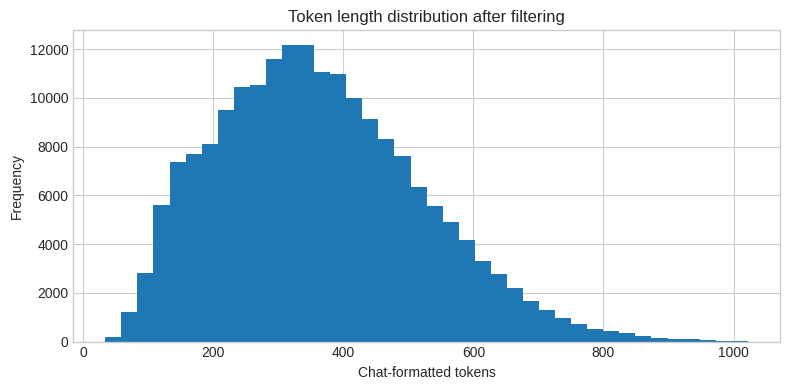

In [4]:
def length_bin(n_tokens: int) -> str:
    if n_tokens <= 192:
        return 'short'
    if n_tokens <= 320:
        return 'medium'
    if n_tokens <= 512:
        return 'long'
    return 'very_long'


def text_block(text: str):
    return [{'type': 'text', 'text': text}]


def make_chat_pair(question: str, answer: str):
    return [
        {'role': 'user', 'content': text_block(question)},
        {'role': 'assistant', 'content': text_block(answer)},
    ]

tokenizer_for_lengths = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

raw_ds = load_dataset(DATASET_NAME, split='train')
raw_df = raw_ds.to_pandas()
dedup_df = raw_df.drop_duplicates(subset=['question']).copy()
print(f'Duplicated rows: {len(raw_df) - len(dedup_df)}')

ds = Dataset.from_pandas(dedup_df, preserve_index=False)

def compute_lengths_batch(batch):
    q_words = [len(str(q).split()) for q in batch['question']]
    a_words = [len(str(a).split()) for a in batch['answer']]

    rendered = [
        tokenizer_for_lengths.apply_chat_template(
            make_chat_pair(q, a),
            tokenize=False,
            add_generation_prompt=False
        )
        for q, a in zip(batch['question'], batch['answer'])
    ]

    encodings = tokenizer_for_lengths(text=rendered, add_special_tokens=False)
    n_tokens = [len(ids) for ids in encodings['input_ids']]

    return {
        'question_words': q_words,
        'answer_words': a_words,
        'n_tokens': n_tokens
    }

num_proc = os.cpu_count() or 2

# 1. Map to calculate token/word lengths in parallel
ds = ds.map(compute_lengths_batch, batched=True, batch_size=1000, num_proc=num_proc)

# 2. Filter using batched mode
def filter_batch(batch):
    return [
        (8 <= qw <= 160) and (8 <= aw <= 360) and (nt <= 1024)
        for qw, aw, nt in zip(batch['question_words'], batch['answer_words'], batch['n_tokens'])
    ]

ds = ds.filter(filter_batch, batched=True, batch_size=1000, num_proc=num_proc)

filtered_df = ds.to_pandas()
filtered_df['difficulty'] = filtered_df['n_tokens'].map(length_bin)
filtered_df['example_id'] = [f'orca_math_{i:06d}' for i in range(len(filtered_df))]

summary_rows = []
for name, frame in [('full_filtered', filtered_df)]:
    summary_rows.append(
        {
            'split': name,
            'rows': len(frame),
            'median_tokens': frame['n_tokens'].median(),
            'p90_tokens': frame['n_tokens'].quantile(0.9),
            'p95_tokens': frame['n_tokens'].quantile(0.95),
            'max_tokens': frame['n_tokens'].max(),
        }
    )
display(pd.DataFrame(summary_rows))

ax = filtered_df['n_tokens'].plot(kind='hist', bins=40, figsize=(8, 4), title='Token length distribution after filtering')
ax.set_xlabel('Chat-formatted tokens')
plt.tight_layout()
plt.show()


Разбиваю датасет на `train` и `valid` сплиты. Делаю стратификацию по сложности вопросов, предполагая, что чем больше `chat-formatted tokens`, тем сложнее была задачка.

In [5]:

from sklearn.model_selection import train_test_split

train_pool, test_pool = train_test_split(
    filtered_df,
    test_size=512,
    random_state=RANDOM_STATE,
    stratify=filtered_df['difficulty'],
)

def stratified_sample(frame: pd.DataFrame, size: int) -> pd.DataFrame:
    if len(frame) <= size:
        return frame.copy()
    sampled, _ = train_test_split(
        frame,
        train_size=size,
        random_state=RANDOM_STATE,
        stratify=frame['difficulty'],
    )
    return sampled.copy()

train_df = stratified_sample(train_pool, 8192).sort_values('example_id').reset_index(drop=True)
valid_df = stratified_sample(test_pool, 256).sort_values('example_id').reset_index(drop=True)

split_df = pd.DataFrame([
    {'split': 'train_df', 'rows': len(train_df), 'median_tokens': train_df['n_tokens'].median(), 'p95_tokens': train_df['n_tokens'].quantile(0.95)},
    {'split': 'valid_df', 'rows': len(valid_df), 'median_tokens': valid_df['n_tokens'].median(), 'p95_tokens': valid_df['n_tokens'].quantile(0.95)},
])
display(split_df)


,split,rows,median_tokens,p95_tokens
0,train_df,8192,349.0000,641.0000
1,valid_df,256,339.5000,684.0000


In [6]:
cleanup_memory("raw_ds",
               "raw_df",
               "filtered_df",
               "train_pool",
               "frame",
               "rendered",
               "search_train",
               "search_valid")

Memory cleanup completed.


Беру только небольшую часть датасета, чтобы уместиться в лимиты Colab.


## 2. Выбор предобученной модели

Выбрал `unsloth/Qwen3.5-0.8B`. Модель достаточно компактна и уже достаточна сильна на математических задачах.


In [7]:
MODEL_NAME = 'unsloth/Qwen3.5-0.8B'
print('unsloth version:', unsloth.__version__)
print('transformers version:', torch.__version__ if False else __import__('transformers').__version__)


unsloth version: 2026.4.7
transformers version: 5.7.0.dev0


## 3. Предварительная оценка качества

До обучения я оцениваю модель двумя способами. Первый, небольшая корзинка математических задач, которые я сам составил. Здесь я сразу использую тот же формат ответа, что и в gsm8k: `Answer: <number>`. Второй, `gsm8k` через `lm-evaluation-harness`.

В качестве benchmark-а я беру `gsm8k`, `5-shot`, `limit=100`. Полный benchmark Colab слишком дорог по времени, а slice на 100 задач уже достаточно информативен для сравнения base и fine-tuned модели.


Для собственной корзинки я не включаю thinking mode, чтобы уменьшить количество генерируемых токенов и уместиться в лимиты colab. `max_new_tokens` я устанавливаю до `1024` и отдельно отслеживаю случаи, когда модель упирается в лимит генерации. Если ответ оказался неверным, я хочу понимать, была ли проблема в рассуждении или модель просто не успела закончить вывод.

In [8]:
BASKET = [
    {
        'id': 'b1',
        'question': 'Question: A store sells 30% of its 200 apples. Then, it receives a new shipment of 50 apples. How many apples does the store have now? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '190',
    },
    {
        'id': 'b2',
        'question': 'Question: John is twice as old as Mary. In 5 years, the sum of their ages will be 34. How old is John now? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '16',
    },
    {
        'id': 'b3',
        'question': 'Question: A tank is filled by two pipes. Pipe A fills it in 3 hours, and Pipe B fills it in 6 hours. How many hours will it take to fill the tank if both pipes are open at the same time? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '2',
    },
    {
        'id': 'b4',
        'question': 'Question: If 3x + 7 = 28, what is the value of x? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '7',
    },
    {
        'id': 'b5',
        'question': 'Question: A jacket originally costs $80. It is discounted by 25%. Later, an additional 10% discount is applied to the sale price. What is the final price in dollars? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '54',
    },
    {
        'id': 'b6',
        'question': 'Question: The sum of three consecutive even integers is 84. What is the largest of these integers? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '30',
    },
    {
        'id': 'b7',
        'question': 'Question: A recipe calls for 2.5 cups of flour to make 10 servings. How many cups of flour are needed to make 24 servings? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '6',
    },
    {
        'id': 'b8',
        'question': 'Question: Emma has $4.50 in quarters and dimes. If she has 24 coins in total, how many quarters does she have? Answer at the end strictly in the format: Answer: <NUMBER>.',
        'correct_number': '14',
    },
]

FINAL_ANSWER_RE = re.compile(r'Answer\s*:\s*(-?\d+(?:[.,]\d+)?)', re.IGNORECASE)

def normalize_number_string(text: str | None):
    if text is None:
        return None
    return str(text).replace(',', '.').strip()

def parse_basket_number(text: str):
    match = FINAL_ANSWER_RE.search(text)
    if match:
        return normalize_number_string(match.group(1))
    # Else: take last number
    numbers = re.findall(r'-?\d+(?:[.,]\d+)?', text.replace(',', '.'))
    return normalize_number_string(numbers[-1]) if numbers else None

basket_df = pd.DataFrame(BASKET)
display(basket_df)

,id,question,correct_number
0,b1,"Question: A store sells 30% of its 200 apples. Then, it receives a new shipment of 50 apples. How many apples does the store have now? Answer at the end strictly in the format: Answer: <NUMBER>.",190
1,b2,"Question: John is twice as old as Mary. In 5 years, the sum of their ages will be 34. How old is John now? Answer at the end strictly in the format: Answer: <NUMBER>.",16
2,b3,"Question: A tank is filled by two pipes. Pipe A fills it in 3 hours, and Pipe B fills it in 6 hours. How many hours will it take to fill the tank if both pipes are open at the same time? Answer at...",2
3,b4,"Question: If 3x + 7 = 28, what is the value of x? Answer at the end strictly in the format: Answer: <NUMBER>.",7
4,b5,"Question: A jacket originally costs $80. It is discounted by 25%. Later, an additional 10% discount is applied to the sale price. What is the final price in dollars? Answer at the end strictly in ...",54
5,b6,Question: The sum of three consecutive even integers is 84. What is the largest of these integers? Answer at the end strictly in the format: Answer: <NUMBER>.,30
6,b7,Question: A recipe calls for 2.5 cups of flour to make 10 servings. How many cups of flour are needed to make 24 servings? Answer at the end strictly in the format: Answer: <NUMBER>.,6
7,b8,"Question: Emma has $4.50 in quarters and dimes. If she has 24 coins in total, how many quarters does she have? Answer at the end strictly in the format: Answer: <NUMBER>.",14


In [9]:
max_seq_length = 2048 # Размер "окна контекста", беру с запасом
basket_generation_config = {
    'max_new_tokens': 1024, # Лимит на кол-во генерируемых токенов
    'enable_thinking': False,
    'do_sample': False, # Сохраняем детерминированность для воспроизводимости.
    # На каждом шаге выбираем токен с наивысшей вероятностью (greedy decoding)
}
base_model, base_tokenizer = load_qwen_4bit(
    MODEL_NAME,
    max_seq_length=max_seq_length,
    for_inference=True,
)


def generate_one(model, tokenizer, prompt: str):
    inputs = tokenizer.apply_chat_template(
        [{'role': 'user', 'content': text_block(prompt)}],
        tokenize=True,
        add_generation_prompt=True,
        return_tensors='pt',
        enable_thinking=basket_generation_config['enable_thinking'],
    )
    input_ids = inputs.to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=basket_generation_config['max_new_tokens'],
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=basket_generation_config['do_sample'],
        )

    new_tokens = outputs[0][input_ids.shape[-1]:]
    return {
        'text': tokenizer.decode(new_tokens, skip_special_tokens=True).strip(),
        'generated_tokens': int(len(new_tokens)),
        'hit_token_limit': len(new_tokens) >= basket_generation_config['max_new_tokens'],
    }


def evaluate_basket(model, tokenizer, basket):
    rows = []
    for item in basket:
        generation = generate_one(model, tokenizer, item['question'])
        pred_number = parse_basket_number(generation['text'])
        rows.append(
            {
                'id': item['id'],
                'correct_number': item['correct_number'],
                'pred_number': pred_number,
                'is_correct': pred_number == item['correct_number'],
                'generated_tokens': generation['generated_tokens'],
                'hit_token_limit': generation['hit_token_limit'],
                'prediction': generation['text'],
            }
        )
    rows_df = pd.DataFrame(rows)
    return {
        'basket_accuracy': rows_df['is_correct'].mean(),
        'token_limit_rate': rows_df['hit_token_limit'].mean(),
        'rows': rows,
    }


base_basket = evaluate_basket(base_model, base_tokenizer, BASKET)
display(pd.DataFrame(base_basket['rows']))
print('Base basket accuracy:', base_basket['basket_accuracy'])
print('Share of basket answers that hit max_new_tokens:', base_basket['token_limit_rate'])

==((====))==  Unsloth 2026.4.7: Fast Qwen3_5 patching. Transformers: 5.7.0.dev0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

,id,correct_number,pred_number,is_correct,generated_tokens,hit_token_limit,prediction
0,b1,190,110,False,137,False,"To find the total number of apples the store has now, we first calculate the number of apples sold and then add the new shipment.\n\n1. **Calculate apples sold:**\n The store sells 30% of 200 ..."
1,b2,16,16,True,306,False,"To solve this problem, let's define the variables for the ages of John and Mary.\n\nLet $J$ be John's current age and $M$ be Mary's current age.\n\nFrom the first sentence, we are given the relati..."
2,b3,2,2,True,299,False,"To find out how long it takes to fill the tank when both pipes are open simultaneously, we first determine the rate at which each pipe fills the tank.\n\n1. **Pipe A's rate**: It takes 3 hours to..."
3,b4,7,7,True,97,False,"To find the value of $x$ in the equation $3x + 7 = 28$, we first isolate $x$ by subtracting 7 from both sides of the equation:\n\n$$3x = 28 - 7$$\n$$3x = 21$$\n\nNext, divide both sides by 3:\n\n$..."
4,b5,54,10,False,1024,True,"To find the final price, we first calculate the discounted price after the initial 25% reduction.\n\n1. **Calculate the discounted price after the first 25% discount:**\n The original price is..."
5,b6,30,30,True,239,False,"To find the largest of the three consecutive even integers whose sum is 84, let the integers be represented as $2n$, $2n+2$, and $2n+4$, where $n$ is an integer.\n\nThe sum of these three integers..."
6,b7,6,30,False,531,False,"To solve this, we can set up a proportion. The ratio of servings to flour is constant.\n\n1. **Calculate the ratio of servings to flour for 10 servings:**\n $$ \frac{10 \text{ servings}}{2.5 \..."
7,b8,14,4,False,1024,True,"To find the number of quarters Emma has, let's break down the information given:\n\n1. **Total number of coins**: 24\n2. **Total value**: $4.50\n3. **Composition**: Emma has a mix of quarters (..."


Base basket accuracy: 0.5
Share of basket answers that hit max_new_tokens: 0.25


По результатам видно, что базовая модель выполняет примерно половину задач из корзины правильно. На два вопроса даны неверные ответы, а еще два не уложились в лимит генерации и превысили 1024 токена, причем это произошло уже после того, как я увеличил лимит с 512 до 1024. Буду считать успехом, если увеличится количество правильных ответов и уменьшится количество токенов на рассуждения.



In [10]:
@cache_results(output_path_attr='output_path')
def run_lm_eval(model_args: str, output_path: Path, eval_config: dict):
    torch.cuda.empty_cache()
    gc.collect()
    results = simple_evaluate(model='hf', model_args=model_args, **eval_config)
    return results

base_eval_path = ARTIFACTS_DIR / 'base_gsm8k_hf_5shot_100.pkl'
gsm8k_eval_config = {
    'tasks': ['gsm8k'],
    'num_fewshot': 5,
    'limit': 100,
    'device': 'cuda',
    'batch_size': 2,
    'random_seed': RANDOM_STATE,
    'numpy_random_seed': RANDOM_STATE,
    'torch_random_seed': RANDOM_STATE,
    'fewshot_random_seed': RANDOM_STATE,
}

base_lm_eval = run_lm_eval(
    model_args=f'pretrained={MODEL_NAME},dtype=float16,trust_remote_code=True',
    output_path=base_eval_path,
    eval_config=gsm8k_eval_config,
)

base_gsm8k = base_lm_eval['results']['gsm8k']['exact_match,flexible-extract']
print('Base gsm8k flexible exact match:', base_gsm8k)
cleanup_memory("base_lm_eval")

Loading cached results from /content/hw5_final_artifacts/base_gsm8k_hf_5shot_100.pkl
Base gsm8k flexible exact match: 0.35
Memory cleanup completed.


## 4. QLoRA-дообучение

Ниже я фиксирую конфигурацию для дообучения.

Обучать будем attention и MLP блок.

- `r = 8` ранг LoRA матрицы. Выбирал между 8 и 16.
- `alpha = 16`:  из дефолтной логики $r \times 2 = 16$
- `dropout = 0`: переобучения не возникает, так что не требуется
- `lr = 5e-5` аккуратный lr, чтобы немного направить модель, и минимизировать риск катастрофического забывания.
- `max_seq_length = 1024`
- `response-only loss`: оставляем расчет loss-а только для ответа, тем самым штрафуем модель только за ошибки в генерации ответа, игнорируя текст вопроса. Ведь нам не нужно генерировать вопросы, нам нужно научиться на них отвечать.
- `адаптация верхних 8 слоёв`. Чтобы уменьшить кол-во обучаемых параметров, мы будем тренировать только 8 верхних слоев модели. Верхние слои трансформера отвечают за высокоуровневую логику, так что имеет смысл именно на них сосредоточиться.
- `adamw_8bit`: оптимизированный по памяти adamw
- `per_device_train_batch_size` и `gradient_accumulation_steps` подобрали чтобы оптимально использовать доступную VRAM
- `use_gradient_checkpointing=unsloth` делаем умный gradient_checkpointing. Чтобы уменьшить использование VRAM, но жертвуем скоростью обучения (надо пересчитывать градиенты).


In [11]:
train_df = train_df.copy()
valid_df = valid_df.copy()
max_seq_length = 1024

def make_messages(question, answer):
    return [
        {'role': 'user', 'content': text_block(question)},
        {'role': 'assistant', 'content': text_block(answer)},
    ]

def encode_batch_with_response_mask(batch, tokenizer=base_tokenizer, max_length=max_seq_length):
    full_texts = []
    prompt_texts = []
    for q, a in zip(batch['question'], batch['answer']):
        messages = make_messages(q, a)
        full_texts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False))
        prompt_texts.append(tokenizer.apply_chat_template(messages[:1], tokenize=False, add_generation_prompt=True))

    # Батч-токенизация работает значительно быстрее
    full_encodings = tokenizer(text=full_texts, add_special_tokens=False, truncation=True, max_length=max_length)
    prompt_encodings = tokenizer(text=prompt_texts, add_special_tokens=False, truncation=True, max_length=max_length)

    batch_input_ids = []
    batch_attention_mask = []
    batch_labels = []

    for full_ids, prompt_ids in zip(full_encodings['input_ids'], prompt_encodings['input_ids']):
        labels = full_ids.copy()
        prompt_len = min(len(prompt_ids), len(labels))
        labels[:prompt_len] = [-100] * prompt_len

        batch_input_ids.append(full_ids)
        batch_attention_mask.append([1] * len(full_ids))
        batch_labels.append(labels)

    return {'input_ids': batch_input_ids, 'attention_mask': batch_attention_mask, 'labels': batch_labels}

def build_encoded_dataset(frame):
    # 1. Конвертируем DataFrame напрямую в Dataset
    ds = Dataset.from_pandas(frame)

    # 2. Применяем функцию батчами с поддержкой мультипроцессорности
    ds = ds.map(
        encode_batch_with_response_mask,
        batched=True,
        batch_size=1000,
        num_proc=os.cpu_count() or 2,
        remove_columns=ds.column_names # удаляем исходные текстовые колонки
    )
    return ds

train_dataset = build_encoded_dataset(train_df)
valid_dataset = build_encoded_dataset(valid_df)

class ResponseOnlyCollator:
  # Дополняем Pad до максимального в батче. Не используем готовые решения,
  # так как они могут перезаписать нам все labels.
    def __init__(self, pad_token_id: int):
        self.pad_token_id = pad_token_id

    def __call__(self, features):
        max_len = max(len(f['input_ids']) for f in features)
        input_ids, attention_mask, labels = [], [], []
        for feature in features:
            pad_len = max_len - len(feature['input_ids'])
            input_ids.append(feature['input_ids'] + [self.pad_token_id] * pad_len)
            attention_mask.append(feature['attention_mask'] + [0] * pad_len)
            labels.append(feature['labels'] + [-100] * pad_len)
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long),
        }

Map (num_proc=48):   0%|          | 0/8192 [00:00<?, ? examples/s]

Map (num_proc=48):   0%|          | 0/256 [00:00<?, ? examples/s]

In [12]:
collator = ResponseOnlyCollator(base_tokenizer.pad_token_id)

In [13]:
top_8_layers = list(range(16, 24))
lora_config = {
    'r': 8,
    'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    'lora_alpha': 16,
    'lora_dropout': 0,
    'bias': 'none',
    'use_gradient_checkpointing': 'unsloth',
    'layers_to_transform': top_8_layers,
}
training_config = {
    'per_device_train_batch_size': 16,
    'per_device_eval_batch_size': 16,
    'gradient_accumulation_steps': 2,
    'num_train_epochs': 5,
    'warmup_steps': 50,
    'learning_rate': 5e-5,
    'lr_scheduler_type': 'cosine',
    'weight_decay': 0.01,
    'logging_steps': 5,
    'eval_steps': 100,
    'save_steps': 100,
    'save_total_limit': 2,
    'eval_strategy': 'steps',
    'save_strategy': 'steps',
    'load_best_model_at_end': True,
    'metric_for_best_model': 'eval_loss',
    'optim': 'adamw_8bit', # сокращает потребление памяти,
    # квантуя состояния оптимизатора в 8 бит
    'report_to': 'none',
    'remove_unused_columns': False,
    'dataloader_num_workers': 2,
    'seed': RANDOM_STATE,
}

In [14]:
from transformers import EarlyStoppingCallback

model, tokenizer = load_qwen_4bit(MODEL_NAME, max_seq_length=max_seq_length)
model = attach_lora(
    model,
    random_state=RANDOM_STATE,
    max_seq_length=max_seq_length,
    lora_config=lora_config,
)

output_dir = ARTIFACTS_DIR / 'qwen35_orca_math_t4'
training_args = TrainingArguments(
    output_dir=str(output_dir),
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(), # bf16 отдает больше бит под степень числа
    **training_config,                   # обучение с ним стабильнее
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
) # Запускаем с EarlyStopping

train_output = trainer.train()
trainer.save_model()
tokenizer.save_pretrained(output_dir)

history_df = pd.DataFrame(trainer.state.log_history)
print(train_output)

==((====))==  Unsloth 2026.4.7: Fast Qwen3_5 patching. Transformers: 5.7.0.dev0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 8,192 | Num Epochs = 5 | Total steps = 1,280
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 2 x 1) = 32
 "-____-"     Trainable parameters = 1,064,960 of 854,050,880 (0.12% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,0.414849,0.415882
200,0.388046,0.395297
300,0.368470,0.385954
400,0.368076,0.380073
500,0.365819,0.377268
600,0.332579,0.374946
700,0.364434,0.373177
800,0.336288,0.371499
900,0.360470,0.370593
1000,0.350900,0.370176


[transformers] Unsloth: Restored added_tokens_decoder metadata in /content/hw5_final_artifacts/qwen35_orca_math_t4/tokenizer_config.json.


TrainOutput(global_step=1280, training_loss=0.36289461962878705, metrics={'train_runtime': 3488.2052, 'train_samples_per_second': 11.742, 'train_steps_per_second': 0.367, 'total_flos': 9.808167919515034e+16, 'train_loss': 0.36289461962878705, 'epoch': 5.0})


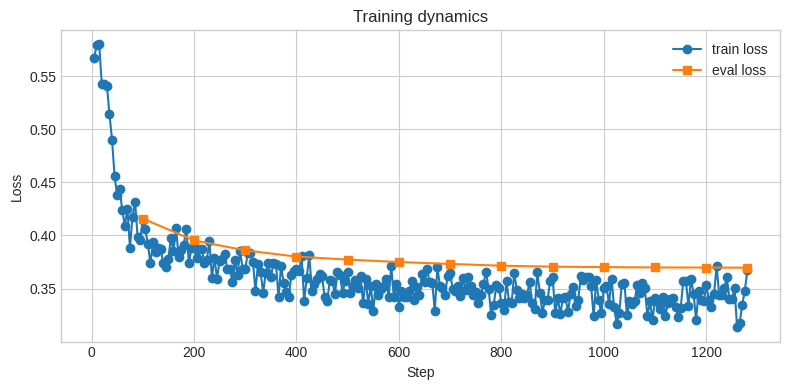

In [15]:

loss_rows = history_df[history_df['loss'].notna()][['step', 'loss']].copy()
eval_rows = history_df[history_df['eval_loss'].notna()][['step', 'eval_loss']].copy()

fig, ax = plt.subplots(figsize=(8, 4))
if not loss_rows.empty:
    ax.plot(loss_rows['step'], loss_rows['loss'], marker='o', label='train loss')
if not eval_rows.empty:
    ax.plot(eval_rows['step'], eval_rows['eval_loss'], marker='s', label='eval loss')
ax.set_title('Training dynamics')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()


По графику видно, что переобучения не происходит.

## 5. Оценка качества после обучения

После обучения я возвращаюсь к тем же двум уровням оценки: корзинка математических задач и `gsm8k`. В корзинке я сохраняю тот же принцип, что и до обучения: модель даёт числовой финал в формате `Answer: <number>`. Это важная дисциплина: если до обучения и после обучения использовать разные протоколы, сравнение почти теряет смысл.


In [16]:
model, tokenizer = load_qwen_4bit(
    str(ARTIFACTS_DIR / 'qwen35_orca_math_t4'),
    max_seq_length=max_seq_length,
    for_inference=True
)

finetuned_basket = evaluate_basket(model, tokenizer, BASKET)

basket_compare = pd.DataFrame([
    {'checkpoint': 'base', 'basket_accuracy': base_basket['basket_accuracy'], 'token_limit_rate': base_basket['token_limit_rate']},
    {'checkpoint': 'finetuned', 'basket_accuracy': finetuned_basket['basket_accuracy'], 'token_limit_rate': finetuned_basket['token_limit_rate']},
])
display(basket_compare)
display(pd.DataFrame(finetuned_basket['rows']))

==((====))==  Unsloth 2026.4.7: Fast Qwen3_5 patching. Transformers: 5.7.0.dev0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

,checkpoint,basket_accuracy,token_limit_rate
0,base,0.5000,0.2500
1,finetuned,0.7500,0.0000


,id,correct_number,pred_number,is_correct,generated_tokens,hit_token_limit,prediction
0,b1,190,110,False,76,False,"First, the store sells 30% of its 200 apples, so it sells 0.30 * 200 = 60 apples.\n\nThen, it receives a new shipment of 50 apples, so it now has 60 + 50 = 110 apples.\n\nAnswer: 110"
1,b2,16,16,True,229,False,"Let's denote John's current age as J and Mary's current age as M.\n\nAccording to the information given, John is twice as old as Mary, so we can write:\nJ = 2M\n\nIn 5 years, John will be J + 5 an..."
2,b3,2,2,True,133,False,"Pipe A fills the tank in 3 hours, so its rate is 1 tank / 3 hours = 1/3 tank per hour.\nPipe B fills the tank in 6 hours, so its rate is 1 tank / 6 hours = 1/6 tank per hour.\nWhen both pipes are ..."
3,b4,7,7,True,62,False,"To find the value of x in the equation 3x + 7 = 28, we first isolate x:\n\n3x = 28 - 7\n3x = 21\nx = 21 / 3\nx = 7\n\nAnswer: 7"
4,b5,54,54,True,89,False,"First, the jacket is discounted by 25%, so the sale price is 75% of the original price:\n0.75 * $80 = $60\n\nThen, an additional 10% discount is applied to the sale price, so the final price is 90..."
5,b6,30,30,True,224,False,"Let the three consecutive even integers be 2n, 2n+2, and 2n+4, where n is an integer.\n\nThe sum of these three integers is 84, so we have:\n\n2n + (2n+2) + (2n+4) = 84\n\nCombining like terms, we..."
6,b7,6,6,True,44,False,"To make 24 servings, you would need 2.5 cups of flour for 10 servings, so you would need 2.5 * 2.4 = 6 cups of flour."
7,b8,14,24,False,411,False,"Emma has $4.50 in quarters and dimes. Since each quarter is worth $0.25 and each dime is worth $0.10, the total value of the quarters is $4.50 - $0.10 = $4.40.\n\nIf Emma has 24 coins in total, an..."


In [17]:
base_df = pd.DataFrame(base_basket['rows'])
ft_df = pd.DataFrame(finetuned_basket['rows'])

comparison_df = pd.merge(
    base_df[['id', 'correct_number', 'is_correct', 'pred_number', 'prediction']],
    ft_df[['id', 'is_correct', 'pred_number', 'prediction']],
    on='id',
    suffixes=('_base', '_ft')
)

comparison_df = pd.merge(comparison_df, basket_df[['id', 'question']], on='id')

outperformed_df = comparison_df[(comparison_df['is_correct_ft'] == True) & (comparison_df['is_correct_base'] == False)]

print(f"Number of questions where finetuned outperformed base: {len(outperformed_df)}")
display(outperformed_df[['id', 'question', 'correct_number', 'pred_number_base', 'prediction_base', 'pred_number_ft', 'prediction_ft']])

Number of questions where finetuned outperformed base: 2


,id,question,correct_number,pred_number_base,prediction_base,pred_number_ft,prediction_ft
4,b5,"Question: A jacket originally costs $80. It is discounted by 25%. Later, an additional 10% discount is applied to the sale price. What is the final price in dollars? Answer at the end strictly in ...",54,10,"To find the final price, we first calculate the discounted price after the initial 25% reduction.\n\n1. **Calculate the discounted price after the first 25% discount:**\n The original price is...",54,"First, the jacket is discounted by 25%, so the sale price is 75% of the original price:\n0.75 * $80 = $60\n\nThen, an additional 10% discount is applied to the sale price, so the final price is 90..."
6,b7,Question: A recipe calls for 2.5 cups of flour to make 10 servings. How many cups of flour are needed to make 24 servings? Answer at the end strictly in the format: Answer: <NUMBER>.,6,30,"To solve this, we can set up a proportion. The ratio of servings to flour is constant.\n\n1. **Calculate the ratio of servings to flour for 10 servings:**\n $$ \frac{10 \text{ servings}}{2.5 \...",6,"To make 24 servings, you would need 2.5 cups of flour for 10 servings, so you would need 2.5 * 2.4 = 6 cups of flour."


In [18]:
# Делаем слияние Lora-адаптера с моделью
merged_dir = ARTIFACTS_DIR / 'qwen35_orca_math_t4_merged'

model.save_pretrained_merged(
    str(merged_dir),
    tokenizer,
    save_method='merged_16bit',
)
del model
gc.collect()
torch.cuda.empty_cache()

finetuned_eval_path = ARTIFACTS_DIR / 'finetuned_gsm8k_hf_5shot_100.json'
gsm8k_eval_config = {
    'tasks': ['gsm8k'],
    'num_fewshot': 5,
    'limit': 100,
    'device': 'cuda',
    'batch_size': 2,
    'random_seed': RANDOM_STATE,
    'numpy_random_seed': RANDOM_STATE,
    'torch_random_seed': RANDOM_STATE,
    'fewshot_random_seed': RANDOM_STATE,
}

finetuned_lm_eval = run_lm_eval(
    model_args=f'pretrained={merged_dir},dtype=float16,trust_remote_code=True',
    output_path=finetuned_eval_path,
    eval_config=gsm8k_eval_config,
)
finetuned_gsm8k = finetuned_lm_eval['results']['gsm8k']['exact_match,flexible-extract']
print('Finetuned gsm8k flexible exact match:', finetuned_gsm8k)


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Running generate_until requests: 100%|██████████| 100/100 [02:53<00:00,  1.74s/it]


Results saved to /content/hw5_final_artifacts/finetuned_gsm8k_hf_5shot_100.json
Finetuned gsm8k flexible exact match: 0.35


,checkpoint,gsm8k_flexible_exact_match
0,base,0.3500
1,finetuned,0.3500


Absolute gain: 0.0


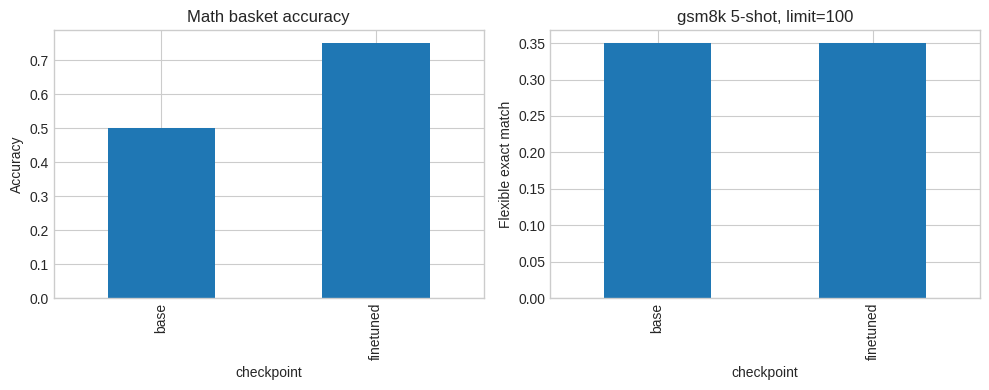

In [19]:

benchmark_compare = pd.DataFrame(
    [
        {'checkpoint': 'base', 'gsm8k_flexible_exact_match': base_gsm8k},
        {'checkpoint': 'finetuned', 'gsm8k_flexible_exact_match': finetuned_gsm8k},
    ]
)
display(benchmark_compare)
print('Absolute gain:', finetuned_gsm8k - base_gsm8k)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
basket_compare.set_index('checkpoint')['basket_accuracy'].plot(kind='bar', ax=axes[0], title='Math basket accuracy')
benchmark_compare.set_index('checkpoint')['gsm8k_flexible_exact_match'].plot(kind='bar', ax=axes[1], title='gsm8k 5-shot, limit=100')
axes[0].set_ylabel('Accuracy')
axes[1].set_ylabel('Flexible exact match')
plt.tight_layout()
plt.show()


## 6. Профайлинг обучения

Профайлер я запускаю на отдельном коротком обучении, чтобы не смешивать диагностику с основным train loop. По трем шагам видно, что один шаг занимает примерно `0.75-0.81` секунды, а loss на этих шагах лежит в диапазоне `0.49-0.64`

In [20]:
# Profiler goes on a short throwaway run so the main training starts from clean weights.
profile_model, _ = load_qwen_4bit(MODEL_NAME, max_seq_length=max_seq_length)
profile_model = attach_lora(
    profile_model,
    random_state=RANDOM_STATE,
    max_seq_length=max_seq_length,
    lora_config=lora_config,
)
profile_model.train()
profile_optimizer = torch.optim.AdamW(
    profile_model.parameters(),
    lr=training_config['learning_rate'],
)
profile_loader = DataLoader(
    train_dataset.select(range(8)),
    batch_size=2,
    shuffle=False,
    collate_fn=collator,
)
profile_trace_dir = ARTIFACTS_DIR / 'torch_profiler'
profile_trace_dir.mkdir(parents=True, exist_ok=True)
profile_rows = []

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
    on_trace_ready=torch.profiler.tensorboard_trace_handler(str(profile_trace_dir)),
) as prof:
    for step, batch in enumerate(profile_loader):
        if step == 3:
            break
        batch = {k: v.to(profile_model.device) for k, v in batch.items()}
        profile_optimizer.zero_grad(set_to_none=True)
        started = time.perf_counter()
        with record_function(f'profile_train_step_{step}'):
            outputs = profile_model(**batch)
            loss = outputs.loss
            loss.backward()
            profile_optimizer.step()
            torch.cuda.synchronize()
        profile_rows.append(
            {
                'step': step,
                'loss': float(loss.detach().cpu()),
                'seconds': time.perf_counter() - started,
            }
        )
        prof.step()

profile_summary = {
    'steps': profile_rows,
    'self_cuda_time_total': prof.key_averages().table(sort_by='self_cuda_time_total', row_limit=15),
    'cuda_memory_usage': prof.key_averages().table(sort_by='cuda_memory_usage', row_limit=15),
    'trace_dir': str(profile_trace_dir),
}
(ARTIFACTS_DIR / 'torch_profiler_summary.json').write_text(json.dumps(profile_summary, ensure_ascii=False, indent=2))

display(pd.DataFrame(profile_rows))
print(profile_summary['self_cuda_time_total'])

cleanup_memory("profile_model",
               "profile_optimizer",
               "profile_loader",
               "profile_rows",
               "profile_summary",
               "profile_trace_dir",
               "prof")


==((====))==  Unsloth 2026.4.7: Fast Qwen3_5 patching. Transformers: 5.7.0.dev0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

,step,loss,seconds
0,0,0.5821,0.8106
1,1,0.4875,0.7528
2,2,0.6394,0.7516


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                   profile_train_step_2         0.00%       0.000us         0.00%       0.000us       0.000us     187.512ms        42.44%     187.512ms     187.512ms           0 B           0 B           0 B           0 

- `aten::copy_` дает около `25%` self CUDA time. Это означает, что заметная доля времени уходит не на математику модели как таковую, а на копирования и перемещения буферов.
- `Optimizer.step#AdamW.step` забирает примерно `19.5%` CUDA-времени: для QLoRA это ожидаемо, потому что trainable параметров мало.
- среди матричных операций видны `aten::bmm` (`13.9%`) и `aten::mm` (`9.9%`), то есть основная полезная вычислительная работа внутри attention и MLP.
- заметный вклад дают операции `aten::mul`, `aten::sum`, `aten::add_`, `aten::fill_`, что типично для LoRA-обучения

По памяти:
- `34.45 GB` у `aten::mul`
- `9.60 GB` у `aten::bmm`

это агрегированная память по всем вызовам этой операции в пределах профиля.

Профиль насыщен большим числом повторяющихся tensor ops, и суммарный memory traffic высок. Это хорошо согласуется с тем, что на коротком профиле self CPU time (`3.998s`) существенно больше self CUDA time (`441.807ms`). Иными словами существенную роль играют Python/dispatcher overhead, частые мелкие операции, копирования и обращения к памяти.

**Резюмируя узкие места**
1. Overhead на работу с памятью (aten::copy_): Занимает ~25% времени GPU. Это говорит о том, что значительная часть времени тратится не на вычисления, а на перекладывание тензоров (вероятно, связано с квантованием, 4-bit операциями и подготовкой батчей).
2. CPU vs GPU time: Self CPU время (4 секунды) почти в 10 раз превышает Self CUDA время (440 мс). Это означает, что узким местом является CPU-оверхед, работа диспетчера PyTorch и запуск множества мелких kernel launches.

## 7. Выводы

Финальный результат получился такой:

На корзинке дообучение дало ощутимую пользу: accuracy выросла с `0.50` до `0.75`, а доля ответов, которые упирались в лимит генерации, снизилась с `0.25` до `0.00`. Одновременно видно, что задача `b1` осталась решенной неверно, а на `b8` модель после дообучения все еще ошибается в вычислении, хотя уже не зацикливается и не упирается в лимит токенов.

На `gsm8k`, `5-shot`, `limit=100` базовая и дообученная модели показали одинаковый результат: `0.35` flexible exact match. Значит, глобально математические способности модели не улучшились, с другой стороны и не ухудшились тоже.

Это означает, что обучение действительно подстроило модель под часть нужных шаблонов решения и сократило лишнюю генерацию, но этого оказалось недостаточно, чтобы получить переносимый выигрыш на более широком срезе `gsm8k`.



In [21]:
import shutil
from google.colab import files

model_path = '/content/hw5_final_artifacts/qwen35_orca_math_t4'
archive_name = '/content/qwen35_orca_math_t4'

print(f"Архивируем папку {model_path}...")
# Создаем zip-архив
shutil.make_archive(archive_name, 'zip', model_path)

print("Запускаем скачивание...")
# Скачиваем созданный архив
files.download(f"{archive_name}.zip")

Архивируем папку /content/hw5_final_artifacts/qwen35_orca_math_t4...
Запускаем скачивание...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>